In [26]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/wine.csv'
import pandas as pd
df = pd.read_csv(file_path)
df
import numpy as np
y = df['Alcohol']
X = df.drop('Alcohol', axis=1)
print(y.head())
print(X.head())
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

Mounted at /content/drive
0    14.23
1    13.20
2    13.16
3    14.37
4    13.24
Name: Alcohol, dtype: float64
   Wine  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1        1.71  2.43  15.6  127     2.80        3.06   
1     1        1.78  2.14  11.2  100     2.65        2.76   
2     1        2.36  2.67  18.6  101     2.80        3.24   
3     1        1.95  2.50  16.8  113     3.85        3.49   
4     1        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  
평균제곱근오차 0.3511470189437248
평균제곱근오차 0.3511470189437248
평균제곱근오차 0.3511470189437248


In [27]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

dt_model = DecisionTreeRegressor(random_state=0)
dt_model.fit(X_train, y_train)
dy_preds = dt_model.predict(X_test)

print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(dy_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(dy_preds, y_test))

평균제곱근오차 0.558966666666667
평균제곱근오차 0.558966666666667
평균제곱근오차 0.5589666666666671


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

dt_model = RandomForestRegressor(n_estimators=100, random_state=0)
dt_model.fit(X_train, y_train)
ry_preds = dt_model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ry_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ry_preds, y_test))

평균제곱근오차 0.45312013844444193
평균제곱근오차 0.45312013844444193
평균제곱근오차 0.45312013844444216


In [29]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)
print('평균제곱오차', mean_squared_error(y_test, knn_preds))
def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, knn_preds))
def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, knn_preds))

평균제곱오차 0.34925911111111185
평균제곱오차 0.34925911111111185
평균제곱오차 0.3492591111111118


/tmp/ipykernel_2895/3583249270.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax)


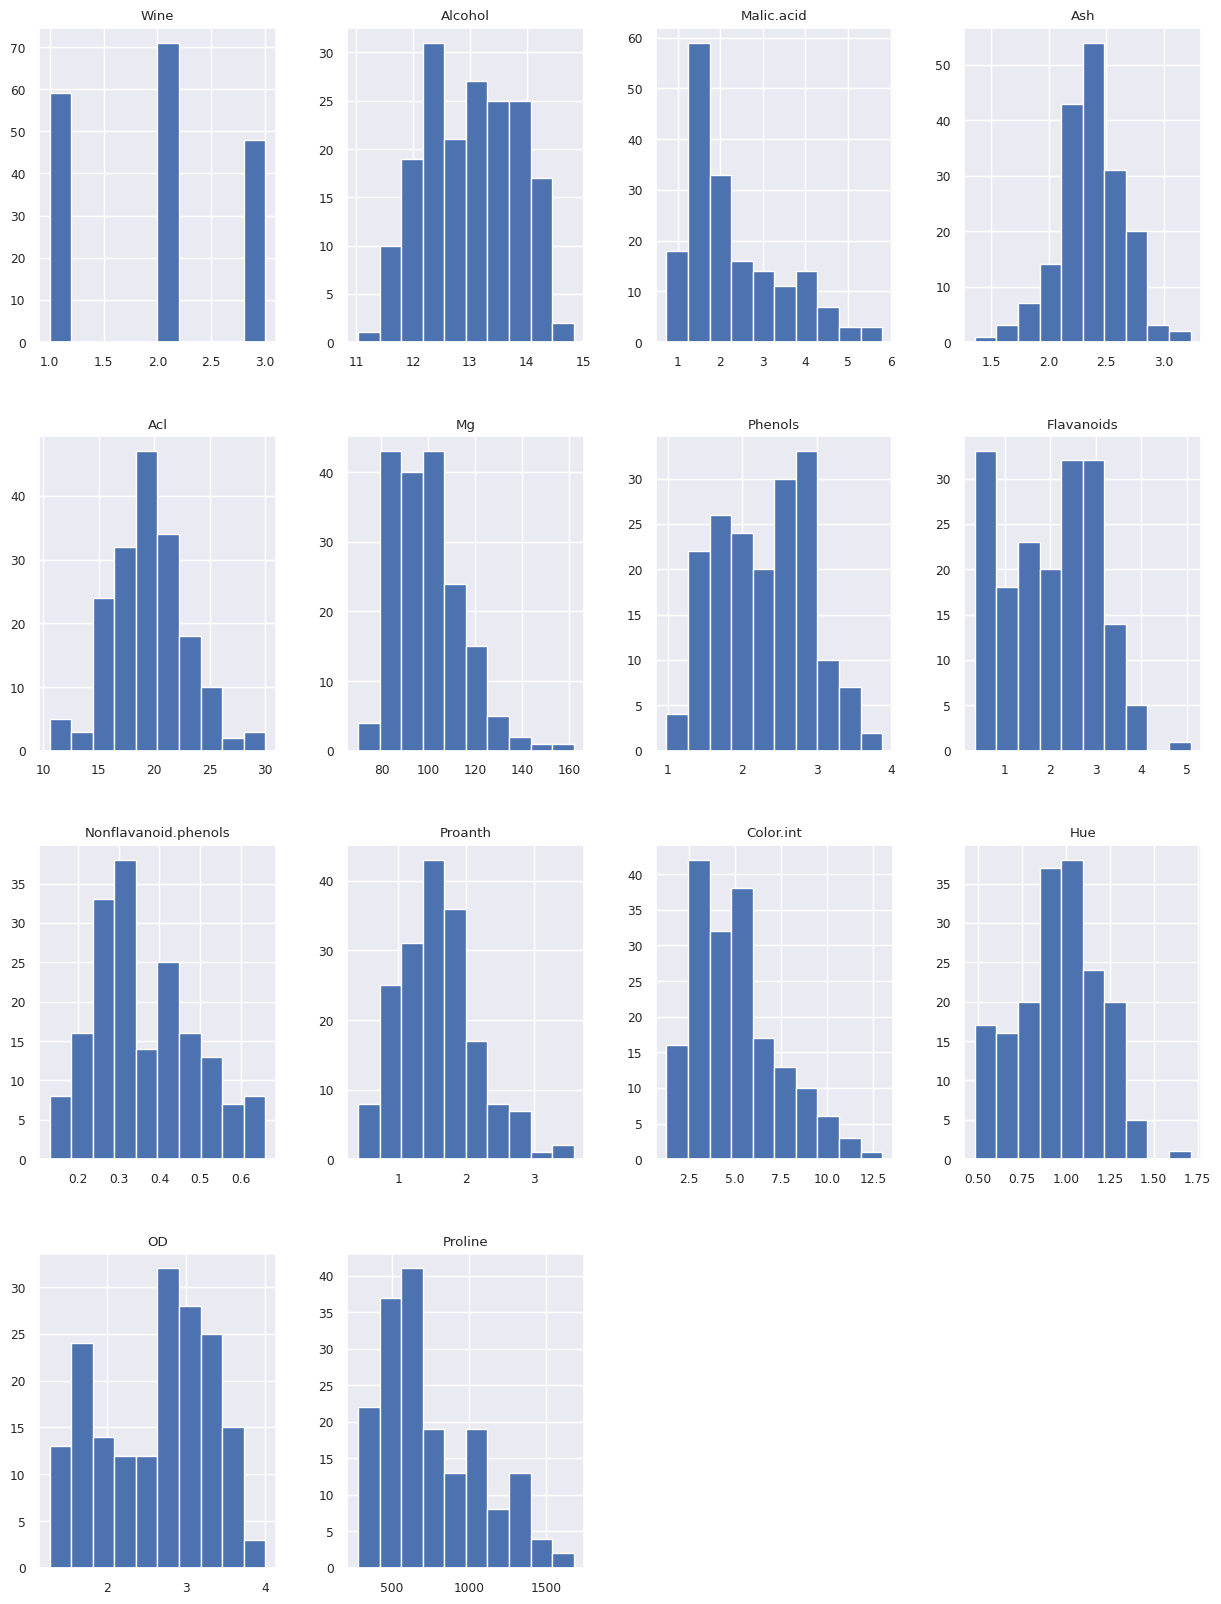

In [30]:

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize = (15,20))
ax = fig.gca()
df.hist(ax = ax)
plt.show()

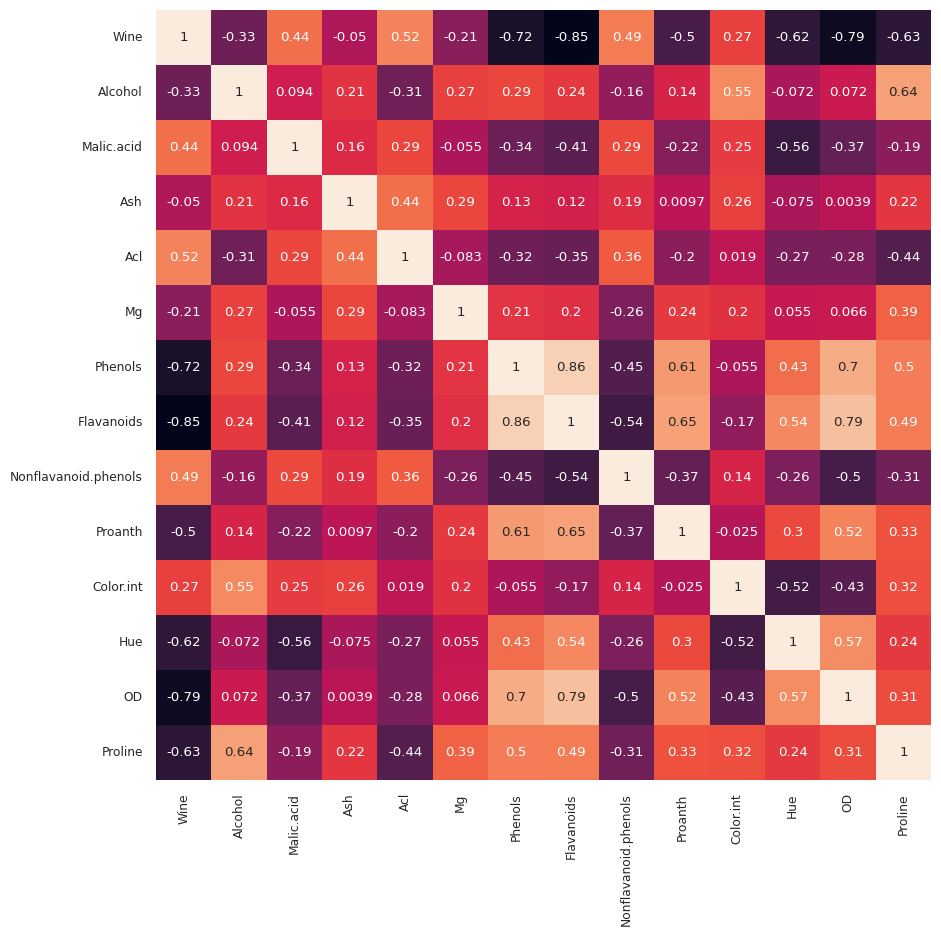

In [31]:
import seaborn as sns
df_corr=df.corr()

plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()



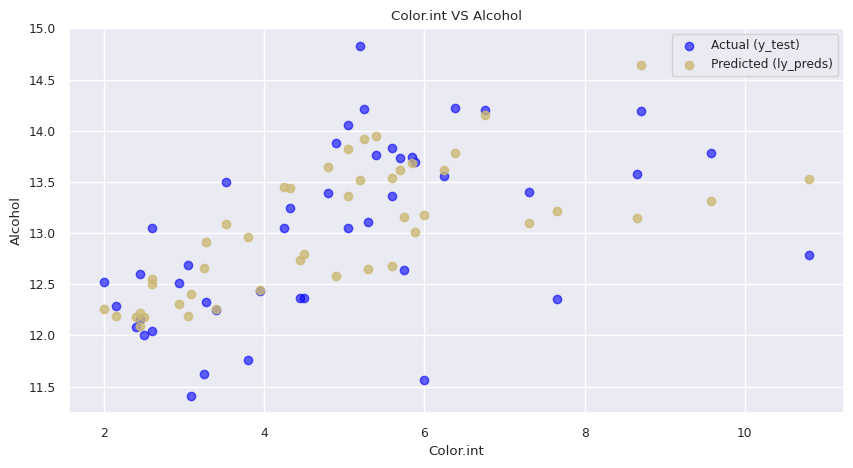

In [32]:
plt.figure(figsize=(10, 5))
plt.scatter(X_test['Color.int'], y_test, label='Actual (y_test)', color='blue', alpha=0.6)
plt.scatter(X_test['Color.int'], ly_preds, c='y', label='Predicted (ly_preds)', alpha=0.8)
plt.xlabel('Color.int')
plt.ylabel('Alcohol')
plt.title('Color.int VS Alcohol')
plt.legend()
plt.show()

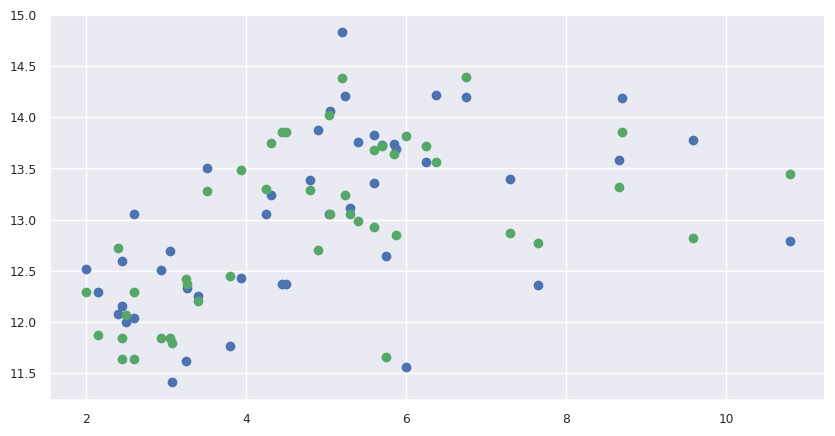

In [36]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Color.int'], y_test, label='y_test')
plt.scatter(X_test['Color.int'], dy_preds, c='g', label='dy_preds')
plt.show()

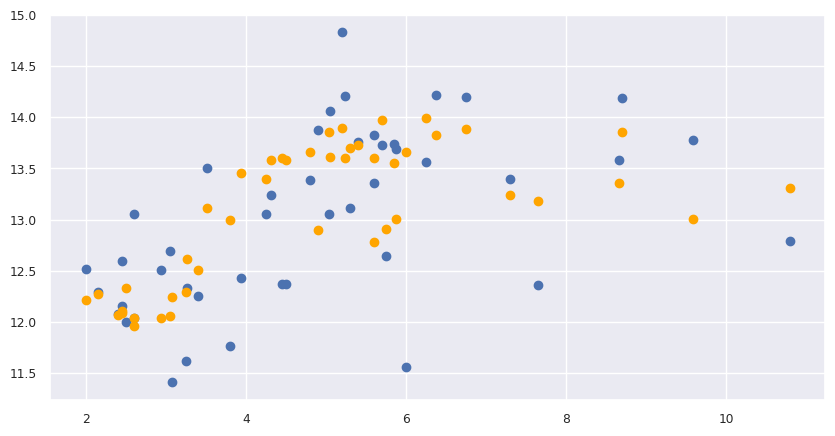

In [34]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Color.int'], y_test, label='y_test')
plt.scatter(X_test['Color.int'], ry_preds, c='orange', label='ry_preds')

plt.show()

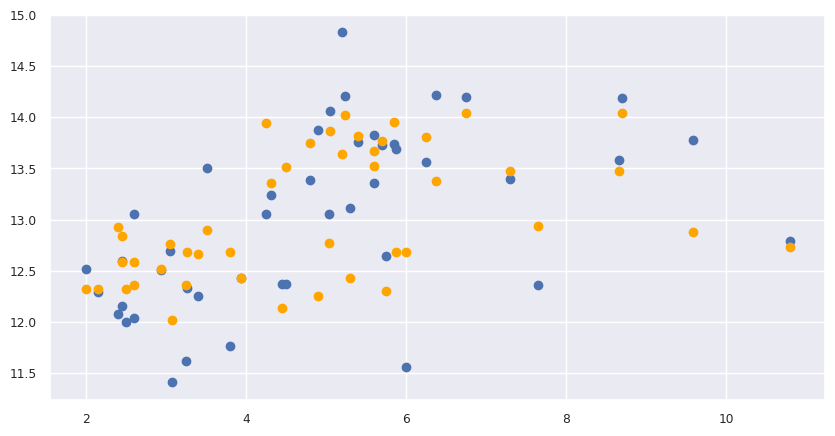

In [35]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Color.int'], y_test, label='y_test')
plt.scatter(X_test['Color.int'], knn_preds, c='orange', label='knn_preds')

plt.show()